![](https://wallpaperaccess.com/full/803470.jpg)

# Soil-Type-Classification for Crops Suggestion 🌳🌲🎄🎋🌴
<br>Problem Statement: Classifying the type of the Soil from Input Image.
# Model deployed as Web-Application API at:🎯🔗📳  <br>
https://soilnet.herokuapp.com/

# GitHub Repo <br>
https://github.com/OMIII1997/Soil-Type-Classification 

# Dataset available at: 📚📓🗞💾 <br>
https://www.kaggle.com/omkargurav/soil-classification-image-data
<br>


For this project a deep learning model is trained with 903 images of four different types soil. "Alluvial", "Black", "Clay" , "Red". All images are collected from Google Search Engine  and crafted and filtered. 
<br>

Based on the type of the Soil Crops will be suggested. Model is deployed on Heroku Platform

# Acknoledgement: 🎓💡🏷🔖📌  <br>
I am expressing my gratitude towards Sir Krish Naik for his super clear explanation about Neural Network in
 Deep Learning Playlist and Model Deployment Tutorial on YouTube.

I am also thankful to Sir Akash Zade for his model deployment explanation at AI in Agri Playlist.


# Click on Below Link for Project Demo: 😍👀🔍📺📡 <br>
https://youtu.be/gnKmbgbPRJA

# Sample:🖥🖨✔🖼📷 <br>
![Image](https://soilnet.herokuapp.com/static/css/images/Clay_2.jpg)

In [1]:
import os
import time
import warnings
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from imutils import paths

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Dense, Dropout, Activation, Flatten, Reshape, Layer,
    BatchNormalization, Conv2D, MaxPooling2D, AveragePooling2D, Input
)
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.17.0


In [2]:
# 1. Configs
INIT_LR = 1e-4
EPOCHS = 15
BS = 32
IMAGE_SIZE = (224, 224)

train_path = 'Dataset/Train'
test_path = 'Dataset/test'

# 2. Data Augmentation & Normalization (Rescale 1./255 மிக முக்கியம்)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Flow from Directory
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BS,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BS,
    class_mode='categorical',
    shuffle=False
)

print("Class Indices:", train_generator.class_indices)

Found 1214 images belonging to 4 classes.
Found 339 images belonging to 4 classes.
Class Indices: {'Alluvial soil': 0, 'Black Soil': 1, 'Clay soil': 2, 'Red soil': 3}


In [3]:
print("Train Class Indices:", train_generator.class_indices)

Train Class Indices: {'Alluvial soil': 0, 'Black Soil': 1, 'Clay soil': 2, 'Red soil': 3}


In [4]:
print("Train Class Indices:", train_generator.class_indices)

Train Class Indices: {'Alluvial soil': 0, 'Black Soil': 1, 'Clay soil': 2, 'Red soil': 3}


# **Creating class for Telegram Bot Message Updates along with Graph**

For complete guidanc and example of making Telegram bot visit here:<br>
https://github.com/OMIII1997/Telegram-Bot-for-Model-Training-Updates <br>

Get access_token from Telegram app: 
* Open Telegram mobile app 
* Search for "BotFather" 
* Send "/start"
* After reply from BotFather send "/newbot"
* Give name to your Bot Eg: Example_Bot
* Give username to your Bot Eg: My_Example_bot *Note: User name must end with '_bot'* 
* Done...Congratulations You have crated your own Telegram bot. Now you will get Token to access the HTTP API. Copy that Token Key.

In [ ]:
import requests
import tensorflow as tf

import tensorflow.keras.utils as np_utils

access_token = '' #Access token here

class botCallback(tf.keras.callbacks.Callback):
    def __init__(self,access_token):
        self.access_token = access_token
        self.ping_url = 'https://api.telegram.org/bot'+str(self.access_token)+'/getUpdates'
        self.response = requests.get(self.ping_url).json()
        #print(self.response)
        self.chat_id = self.response['result'][0]['message']['chat']['id']
        #self.chat_id = self.response['result']

    def send_message(self,message):
        #print('sending message')
        self.ping_url = 'https://api.telegram.org/bot'+str(self.access_token)+'/sendMessage?'+\
                        'chat_id='+str(self.chat_id)+\
                        '&parse_mode=Markdown'+\
                        '&text='+message
        self.response = requests.get(self.ping_url)
    
    def send_photo(self,filepath):
        imagefile= open(filepath,"rb")
        file_dict = {'photo':imagefile}
        self.ping_url = 'https://api.telegram.org/bot'+str(self.access_token)+'/sendPhoto?chat_id='+str(self.chat_id)
        self.response = requests.post(self.ping_url, files = file_dict)
        imagefile.close()

    def on_train_batch_begin(self, batch, logs=None):
        pass
    
    def on_train_batch_end(self, batch, logs=None):
        message = ' Iteration/Batch {}\n Training Accuracy : {:7.2f}\n Training Loss : {:7.2f}\n'.format(batch,logs['accuracy'],logs['loss'])
        #print(logs)
        try:
            message += ' Validation Accuracy : {:7.2f}\n Validation Loss : {:7.2f}\n'.format(logs['val_accuracy'],logs['val_loss'])
            self.send_message(message)
        except:
            pass

    def on_test_batch_begin(self, batch, logs=None):
        pass
    
    def on_test_batch_end(self, batch, logs=None):
        message = ' Iteration/Batch {}\n Training Accuracy : {:7.2f}\n Training Loss : {:7.2f}\n'.format(batch,logs['accuracy'],logs['loss'])
        try:
            message += ' Validation Accuracy : {:7.2f}\n Validation Loss : {:7.2f}\n'.format(logs['val_accuracy'],logs['val_loss'])
            self.send_message(message)
        except:
            pass

    def on_epoch_begin(self, epoch, logs=None):
        pass

    def on_epoch_end(self, epoch, logs=None):

        message = ' Epoch {}\n Training Accuracy : {:7.2f}\n Training Loss : {:7.2f}\n'.format(epoch,logs['accuracy'],logs['loss'])
        try:
            message += ' Validation Accuracy : {:7.2f}\n Validation Loss : {:7.2f}\n'.format(logs['val_accuracy'],logs['val_loss'])
            self.send_message(message)        
        except:
            pass

class Plotter(botCallback):
 def __init__(self,access_token):
    
     super().__init__(access_token)
 def on_train_begin(self,logs=None):
     self.batch = 0
     self.epoch = []
     self.train_loss = []
     self.val_loss = []
     self.train_acc = []
     self.val_acc = []
     self.fig = plt.figure(figsize=(200,100))
     self.logs = []

 def on_epoch_end(self, epoch, logs=None):
     self.logs.append(logs)
     self.epoch.append(epoch)
     self.train_loss.append(logs['loss'])
     self.val_loss.append(logs['val_loss'])
     self.train_acc.append(logs['accuracy'])
     self.val_acc.append(logs['val_accuracy'])
     f,(ax1,ax2) = plt.subplots(1,2,sharex=True)
     #clear_output(wait=True)
     ax1.plot(self.epoch, self.train_loss, label='Training Loss')
     ax1.plot(self.epoch, self.val_loss, label='Validation Loss')
     ax1.legend()
     ax2.plot(self.epoch, self.train_acc, label='Training Accuracy')
     ax2.plot(self.epoch, self.val_acc, label='Validation Accuracy')
     ax2.legend()
     plt.savefig('Accuracy and Loss plot.jpg')
     self.send_photo('Accuracy and Loss plot.jpg')

In [ ]:

train_dir = '/kaggle/input/soil-classification-image-data/Soil_Dataset/Train'
test_dir = '/kaggle/input/soil-classification-image-data/Soil_Dataset/Test'

image_size = 224

In [ ]:
batch_size = 32

train_datagen = ImageDataGenerator(rescale = 1./255,
                            rotation_range=45,
                            zoom_range=0.40,
                            width_shift_range=0.2,
                            height_shift_range=0.2,
                            shear_range=0.15,
                            horizontal_flip=True,
                            vertical_flip= True,
                            fill_mode="nearest")

train_data = train_datagen.flow_from_directory(train_dir,
                                              target_size=(150,150),
                                              batch_size=32,
                                              class_mode="categorical")


In [ ]:
test_datagen = ImageDataGenerator(rescale = 1./255)

test_data = test_datagen.flow_from_directory(test_dir,
                                            target_size=(150,150),
                                            batch_size=32,
                                            class_mode="categorical")

In [ ]:

#=================================================================
chanDim = 1
model = Sequential(name="SoilNet")
model.add(Conv2D(32, (3, 3), padding="same",input_shape=(150,150,3)))
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (4, 4), padding="same"))
model.add(Activation("relu"))

model.add(Conv2D(64, (4, 4), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (4, 4), padding="same"))
model.add(Activation("relu"))

model.add(Conv2D(128, (4, 4), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(1024))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(4))
model.add(Activation("softmax"))


model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
reduction_lr = ReduceLROnPlateau(monitor = "val_accuracy",patience = 2 ,verbose = 1, factor = 0.2, min_lr = 0.00001)
model.summary()
plot_model(model,show_shapes=True)


In [ ]:
callback_list = [reduction_lr]

In [ ]:
#bot_callback = botCallback(access_token)
#plotter = Plotter(access_token)
#callback_list = [bot_callback,plotter] callbacks=callback_list
start = time.time()

history = model.fit_generator(train_data,
                    steps_per_epoch = 30,
                    validation_data = test_data,
                    validation_steps = 30,
                    epochs=20,
                    callbacks = callback_list)
end = time.time()
print("Total train time: ",(end-start)/60," mins")

In [ ]:
def plot_graph(history,string):
    plt.figure(figsize=(12,8))
    plt.plot(history.history[string],label=str(string))
    plt.plot(history.history["val_"+str(string)],label="val_"+str(string))
    plt.xlabel("Epochs")
    plt.ylabel(str(string))
    plt.legend()
    plt.show()
plot_graph(history,"accuracy")
plot_graph(history,"loss")

In [ ]:
model.save("SoilNet.h5")

In [ ]:
from IPython.display import FileLink
FileLink('SoilNet.h5')


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Hyperparameters
IMAGE_SIZE = (128, 128)  # Fixed 128x128 resolution
BATCH_SIZE = 32
EPOCHS = 15
INIT_LR = 1e-4

train_path = 'Dataset/Train'
test_path = 'Dataset/test'

# 2. Data Generators with Rescaling (CRITICAL)
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalizes pixels between 0 and 1
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# PRINT CLASS INDICES - Save this output!
print("--- TRAINED CLASS INDICES ---")
print(train_generator.class_indices)
print("-----------------------------")

# 3. Model Architecture (Using GlobalAveragePooling2D for size flexibility)
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(128, 128, 3)))

for layer in baseModel.layers:
    layer.trainable = False

x = baseModel.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(len(train_generator.class_indices), activation="softmax")(x)

model = Model(inputs=baseModel.input, outputs=outputs)

# 4. Compile & Fit
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=INIT_LR), metrics=["accuracy"])

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)

# 5. Save the retrained model
model.save("SoilNet_93_86.h5")
print("Model retrained and saved successfully as SoilNet_93_86.h5")

Found 1214 images belonging to 4 classes.
Found 339 images belonging to 4 classes.
--- TRAINED CLASS INDICES ---
{'Alluvial soil': 0, 'Black Soil': 1, 'Clay soil': 2, 'Red soil': 3}
-----------------------------
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.3433 - loss: 1.6650 - val_accuracy: 0.3864 - val_loss: 1.2238
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 691ms/step - accuracy: 0.5390 - loss: 1.1209 - val_accuracy: 0.5103 - val_loss: 1.0713
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 705ms/step - accuracy: 0.6457 - loss: 0.9069 - val_accuracy: 0.5811 - val_loss: 0.9902
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 683ms/step - accuracy: 0.6798 - loss: 0.8352 - val_accuracy: 0.6696 - val_loss: 0.8933
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 734ms/step - accuracy: 0.7342 - loss: 0.7198 - val_accuracy: 0.6814 - val_loss: 0.8375
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 694ms/step - accuracy: 0.7433 - loss: 0.6766 - val_accu

Model retrained and saved successfully as SoilNet_93_86.h5


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 15

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'Dataset/Train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    'Dataset/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Print Class Mapping Output
print("\n--- NEW CLASS INDICES ---")
print(train_generator.class_indices)
print("-------------------------\n")

# Model Architecture (5 Classes)
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(128, 128, 3)))
for layer in baseModel.layers:
    layer.trainable = False

x = baseModel.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(5, activation="softmax")(x)

model = Model(inputs=baseModel.input, outputs=outputs)
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=1e-4), metrics=["accuracy"])

model.fit(train_generator, epochs=EPOCHS, validation_data=test_generator)

# Save New Model
model.save("SoilNet_93_86.h5")
print("\nNew SoilNet_93_86.h5 saved successfully!")

Found 1314 images belonging to 5 classes.
Found 439 images belonging to 5 classes.

--- NEW CLASS INDICES ---
{'Alluvial soil': 0, 'Black Soil': 1, 'Clay soil': 2, 'Invalid': 3, 'Red soil': 4}
-------------------------

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 855ms/step - accuracy: 0.2640 - loss: 2.0393 - val_accuracy: 0.4715 - val_loss: 1.2287
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 698ms/step - accuracy: 0.5086 - loss: 1.2899 - val_accuracy: 0.5854 - val_loss: 0.9676
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 677ms/step - accuracy: 0.6398 - loss: 0.9720 - val_accuracy: 0.6811 - val_loss: 0.8258
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 31s 673ms/step - accuracy: 0.6973 - loss: 0.8545 - val_accuracy: 0.6993 - val_loss: 0.7617
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 680ms/step - accuracy: 0.7202 - loss: 0.7597 - val_accuracy: 0.7016 - val_loss: 0.7316
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 669ms/step - accuracy: 0.7111 - loss: 0.7104 - val_accuracy: 0.7540 - val_loss: 0.6539
Epoch 


New SoilNet_93_86.h5 saved successfully!


In [7]:
import os

def count_images(dataset_path):
    print(f"--- Folder: {dataset_path} ---")
    if not os.path.exists(dataset_path):
        print("Folder கிடைக்கவில்லை! Path-ஐ சரிபார்க்கவும்.")
        return
        
    total_count = 0
    for folder_name in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder_name)
        if os.path.isdir(folder_path):
            images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            count = len(images)
            total_count += count
            print(f"📂 {folder_name:<15} : {count} படங்கள்")
            
    print(f"👉 மொத்த படங்கள் : {total_count}\n")

# Train மற்றும் Test Folder-ல் உள்ள படங்களை எண்ணுதல்
count_images('Dataset/Train')
count_images('Dataset/test')

--- Folder: Dataset/Train ---
📂 Alluvial soil   : 525 படங்கள்
📂 Black Soil      : 228 படங்கள்
📂 Clay soil       : 199 படங்கள்
📂 Invalid         : 100 படங்கள்
📂 Red soil        : 262 படங்கள்
👉 மொத்த படங்கள் : 1314

--- Folder: Dataset/test ---
📂 Alluvial soil   : 54 படங்கள்
📂 Black Soil      : 55 படங்கள்
📂 Clay soil       : 55 படங்கள்
📂 Invalid         : 55 படங்கள்
📂 Red soil        : 55 படங்கள்
👉 மொத்த படங்கள் : 274



In [8]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Data Augmentation generator
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Target images count per class in Train folder
TARGET_COUNT = 250
train_dir = 'Dataset/Train'

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    if os.path.isdir(folder_path):
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        current_count = len(images)
        
        # If images are less than TARGET_COUNT, create new augmented images
        if current_count < TARGET_COUNT:
            needed = TARGET_COUNT - current_count
            print(f"🔄 Generating {needed} extra images for '{folder}'...")
            
            i = 0
            while i < needed:
                for img_name in images:
                    if i >= needed:
                        break
                    img_path = os.path.join(folder_path, img_name)
                    img = load_img(img_path)
                    x = img_to_array(img)
                    x = x.reshape((1,) + x.shape)
                    
                    # Generate 1 image
                    for batch in datagen.flow(x, batch_size=1, save_to_dir=folder_path, save_prefix='aug', save_format='jpg'):
                        i += 1
                        break

print("\n அனைத்து Folders-லும் படங்கள் வெற்றிகரமாகச் சமமாக்கப்பட்டுவிட்டன!")

🔄 Generating 22 extra images for 'Black Soil'...
🔄 Generating 51 extra images for 'Clay soil'...
🔄 Generating 150 extra images for 'Invalid'...

 அனைத்து Folders-லும் படங்கள் வெற்றிகரமாகச் சமமாக்கப்பட்டுவிட்டன!


In [9]:
import os

def count_images(dataset_path):
    print(f"--- Folder: {dataset_path} ---")
    if not os.path.exists(dataset_path):
        print("Folder கிடைக்கவில்லை! Path-ஐ சரிபார்க்கவும்.")
        return
        
    total_count = 0
    for folder_name in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder_name)
        if os.path.isdir(folder_path):
            images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            count = len(images)
            total_count += count
            print(f"📂 {folder_name:<15} : {count} படங்கள்")
            
    print(f"👉 மொத்த படங்கள் : {total_count}\n")

# Train மற்றும் Test Folder-ல் உள்ள படங்களை எண்ணுதல்
count_images('Dataset/Train')
count_images('Dataset/test')

--- Folder: Dataset/Train ---
📂 Alluvial soil   : 525 படங்கள்
📂 Black Soil      : 250 படங்கள்
📂 Clay soil       : 250 படங்கள்
📂 Invalid         : 250 படங்கள்
📂 Red soil        : 262 படங்கள்
👉 மொத்த படங்கள் : 1537

--- Folder: Dataset/test ---
📂 Alluvial soil   : 54 படங்கள்
📂 Black Soil      : 55 படங்கள்
📂 Clay soil       : 55 படங்கள்
📂 Invalid         : 55 படங்கள்
📂 Red soil        : 55 படங்கள்
👉 மொத்த படங்கள் : 274



In [10]:
import os
import random

# Alluvial soil folder path
alluvial_folder = 'Dataset/Train/Alluvial soil'
TARGET_COUNT = 250

if os.path.exists(alluvial_folder):
    # Get all images in Alluvial soil folder
    images = [f for f in os.listdir(alluvial_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    current_count = len(images)
    
    print(f"தற்போதைய Alluvial soil படங்கள் எண்ணிக்கை: {current_count}")
    
    if current_count > TARGET_COUNT:
        to_delete_count = current_count - TARGET_COUNT
        
        # Randomly choose images to delete
        images_to_delete = random.sample(images, to_delete_count)
        
        for img_name in images_to_delete:
            file_path = os.path.join(alluvial_folder, img_name)
            os.remove(file_path)
            
        print(f"🗑️ {to_delete_count} படங்கள் நீக்கப்பட்டுவிட்டன!")
        print(f"✅ இப்போது Alluvial soil கோப்புறையில் மீதம் உள்ள படங்கள்: {TARGET_COUNT}")
    else:
        print("படங்களின் எண்ணிக்கை ஏற்கனவே 250 அல்லது அதற்கு குறைவாக உள்ளது.")
else:
    print("Folder கிடைக்கவில்லை! Path-ஐ சரிபார்க்கவும்.")

தற்போதைய Alluvial soil படங்கள் எண்ணிக்கை: 525
🗑️ 275 படங்கள் நீக்கப்பட்டுவிட்டன!
✅ இப்போது Alluvial soil கோப்புறையில் மீதம் உள்ள படங்கள்: 250


In [11]:
import os

def count_images(dataset_path):
    print(f"--- Folder: {dataset_path} ---")
    if not os.path.exists(dataset_path):
        print("Folder கிடைக்கவில்லை! Path-ஐ சரிபார்க்கவும்.")
        return
        
    total_count = 0
    for folder_name in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder_name)
        if os.path.isdir(folder_path):
            images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            count = len(images)
            total_count += count
            print(f"📂 {folder_name:<15} : {count} படங்கள்")
            
    print(f"👉 மொத்த படங்கள் : {total_count}\n")

# Train மற்றும் Test Folder-ல் உள்ள படங்களை எண்ணுதல்
count_images('Dataset/Train')
count_images('Dataset/test')

--- Folder: Dataset/Train ---
📂 Alluvial soil   : 250 படங்கள்
📂 Black Soil      : 250 படங்கள்
📂 Clay soil       : 250 படங்கள்
📂 Invalid         : 250 படங்கள்
📂 Red soil        : 262 படங்கள்
👉 மொத்த படங்கள் : 1262

--- Folder: Dataset/test ---
📂 Alluvial soil   : 55 படங்கள்
📂 Black Soil      : 55 படங்கள்
📂 Clay soil       : 55 படங்கள்
📂 Invalid         : 55 படங்கள்
📂 Red soil        : 55 படங்கள்
👉 மொத்த படங்கள் : 275



In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20

# Data Generator Setup
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'Dataset/Train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    'Dataset/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Base Model (Fine-tuning)
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(128, 128, 3)))
baseModel.trainable = True
for layer in baseModel.layers[:-20]:
    layer.trainable = False

x = baseModel.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(5, activation="softmax")(x)

model = Model(inputs=baseModel.input, outputs=outputs)
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=1e-4), metrics=["accuracy"])

# Training Process
model.fit(train_generator, epochs=EPOCHS, validation_data=test_generator)

# Save `.h5` file
model.save("SoilNet_93_86.h5")
print("\n✅ New Trained Model Saved Successfully!")

Found 1262 images belonging to 5 classes.
Found 275 images belonging to 5 classes.
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 792ms/step - accuracy: 0.4483 - loss: 1.4434 - val_accuracy: 0.6327 - val_loss: 1.0529
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 656ms/step - accuracy: 0.7768 - loss: 0.5947 - val_accuracy: 0.6436 - val_loss: 0.9817
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 638ms/step - accuracy: 0.8386 - loss: 0.5004 - val_accuracy: 0.6509 - val_loss: 1.0992
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 648ms/step - accuracy: 0.8785 - loss: 0.3603 - val_accuracy: 0.6327 - val_loss: 1.1586
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 661ms/step - accuracy: 0.8899 - loss: 0.3222 - val_accuracy: 0.7200 - val_loss: 0.8966
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 656ms/step - accuracy: 0.8842 - loss: 0.3099 - val_accuracy: 0.7091 - val_loss: 0.9329
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 651ms/step - accuracy: 0.9161 - loss: 0.2521 - val_accuracy: 0.7745 - val_loss: 0.7358
Epoch 8/20
40/


✅ New Trained Model Saved Successfully!


In [13]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Test data-வில் இருந்து கணிப்புகளைப் பெறுதல்
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# 1. ஒட்டுமொத்த Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"📊 Overall Model Accuracy: {acc * 100:.2f}%\n")

# 2. ஒவ்வொரு வகுப்பிற்குமான துல்லிய அறிக்கை (Classification Report)
class_labels = list(test_generator.class_indices.keys())
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 661ms/step
📊 Overall Model Accuracy: 85.82%

--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

Alluvial soil       1.00      0.42      0.59        55
   Black Soil       0.75      1.00      0.86        55
    Clay soil       0.86      0.93      0.89        55
      Invalid       1.00      1.00      1.00        55
     Red soil       0.80      0.95      0.87        55

     accuracy                           0.86       275
    macro avg       0.88      0.86      0.84       275
 weighted avg       0.88      0.86      0.84       275



In [14]:
# Learning Rate-ஐ 1e-4 லிருந்து 1e-5 ஆகக் குறைப்பதால் Alluvial soil-ன் சிறப்பம்சங்களை மாடல் சரியாகக் கற்கும்
model.compile(
    loss="categorical_crossentropy", 
    optimizer=Adam(learning_rate=1e-5), 
    metrics=["accuracy"]
)

# Epochs-ஐ 30 ஆக உயர்த்தவும்
EPOCHS = 30
model.fit(train_generator, epochs=EPOCHS, validation_data=test_generator)

# Save updated model
model.save("SoilNet_93_86.h5")

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 750ms/step - accuracy: 0.9510 - loss: 0.1163 - val_accuracy: 0.8727 - val_loss: 0.8442
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 664ms/step - accuracy: 0.9698 - loss: 0.0909 - val_accuracy: 0.8764 - val_loss: 0.8089
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 661ms/step - accuracy: 0.9611 - loss: 0.1127 - val_accuracy: 0.8836 - val_loss: 0.7811
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 639ms/step - accuracy: 0.9650 - loss: 0.1081 - val_accuracy: 0.8873 - val_loss: 0.7438
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 645ms/step - accuracy: 0.9562 - loss: 0.1238 - val_accuracy: 0.8836 - val_loss: 0.6938
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 644ms/step - accuracy: 0.9747 - loss: 0.0686 - val_accuracy: 0.8836 - val_loss: 0.7152
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 659ms/step - accuracy: 0.9774 - loss: 0.0834 - val_accuracy: 0.8873 - val_loss: 0.7107
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 646ms/step - accuracy: 0.9722 - loss: 0.0879 - val_accu

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3], # நிறம்/வெளிச்ச மாறுபாடுகளைப் புரிந்துகொள்ள உதவும்
    zoom_range=0.2,
    horizontal_flip=True
)

In [16]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Test data-வில் இருந்து கணிப்புகளைப் பெறுதல்
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# 1. ஒட்டுமொத்த Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"📊 Overall Model Accuracy: {acc * 100:.2f}%\n")

# 2. ஒவ்வொரு வகுப்பிற்குமான துல்லிய அறிக்கை (Classification Report)
class_labels = list(test_generator.class_indices.keys())
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 619ms/step
📊 Overall Model Accuracy: 91.64%

--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

Alluvial soil       1.00      0.64      0.78        55
   Black Soil       0.92      1.00      0.96        55
    Clay soil       0.82      0.96      0.88        55
      Invalid       1.00      1.00      1.00        55
     Red soil       0.90      0.98      0.94        55

     accuracy                           0.92       275
    macro avg       0.93      0.92      0.91       275
 weighted avg       0.93      0.92      0.91       275



In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix கணக்கிடுதல்
cm = confusion_matrix(y_true, y_pred)

# Heatmap வரைபடம் அமைத்தல்
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)

plt.title('Soil Classification - Confusion Matrix')
plt.xlabel('Predicted Label (கணிக்கப்பட்ட வகுப்பு)')
plt.ylabel('True Label (உண்மையான வகுப்பு)')
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [18]:
model.save("SoilNet_93_86.h5")

In [19]:
!pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ----- ---------------------------------- 41.0/294.9 kB 1.9 MB/s eta 0:00:01
   ---------------- ----------------------- 122.9/294.9 kB 1.8 MB/s eta 0:00:01
   --------------------------- ------------ 204.8/294.9 kB 1.8 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.3 MB 4.8 MB/s eta 0:00:03
    --------------------------------------- 0.2/11.3 MB 2.4 MB/s eta 0:00:05
   - -------------------------------------- 0.3/11.3 MB 2.5 MB/s eta 0:00:05
   - -------------------------------------- 0.5/11.3 MB 2.6 MB/s eta 0:00:05
   -- ------------------------------------- 0.6/11.3 MB 2.6 MB/s eta 0:00:05
   -- ------------------------------------- 0.7/11.3 MB 2.7 MB/s eta 0:00:0


[notice] A new release of pip is available: 24.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


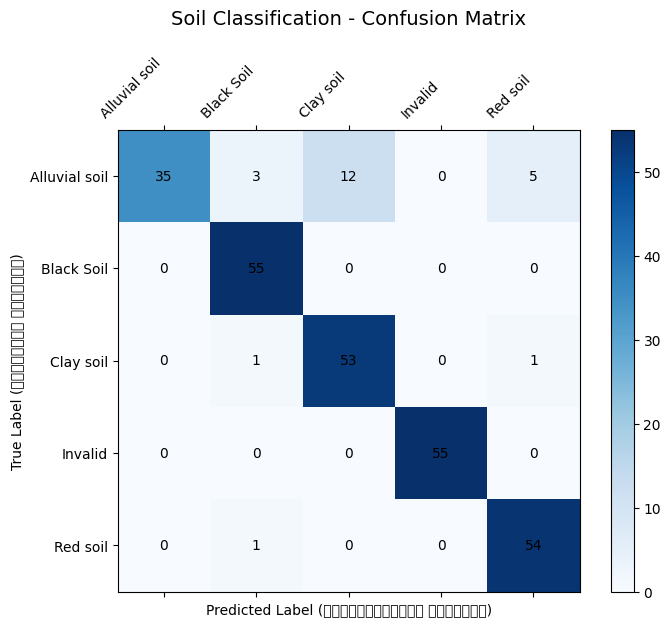

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Confusion Matrix கணக்கிடுதல்
cm = confusion_matrix(y_true, y_pred)

# Matplotlib வரைபடம்
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

# லேபிள்கள் அமைத்தல்
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.set_yticklabels(class_labels)

# எண்களை வரைபடத்தில் காட்டுதல்
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.title('Soil Classification - Confusion Matrix\n', fontsize=14)
plt.xlabel('Predicted Label (கணிக்கப்பட்ட வகுப்பு)')
plt.ylabel('True Label (உண்மையான வகுப்பு)')
plt.show()

In [21]:
# Save model in HDF5 format
model.save("SoilNet_93_86.h5")
print("✅ Model saved successfully as SoilNet_93_86.h5!")

✅ Model saved successfully as SoilNet_93_86.h5!
